### Inference from the trained model ###

In [1]:
import sys
import os
import numpy as np
import json
import copy
import glob
import pandas as pd
from pandas.api.types import CategoricalDtype
import logging
from dotenv import load_dotenv
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
from sklearn import metrics as skmetrics
import seaborn as sns

logger = logging.getLogger(__name__)
np.set_printoptions(legacy='1.25')

# PyTorch
import torch
from torchvision import ops
import albumentations as alb

%load_ext autoreload
%autoreload 2
import computervision
from computervision.dentex import Dentex
from computervision.imageproc import is_image, ImageData, clipxywh, xyxy2xywh, xywh2xyxy, plot_boxes
from computervision.datasets import DETRdataset
from computervision.transformations import AugmentationTransform
from computervision.performance import DetectionMetrics
from computervision.inference import DETRinference, get_gpu_info
from computervision.fileutils import FileOP

print(f'Project version: {computervision.__version__}')
print(f'Authors: {computervision.__authors__}')
print(f'Python version:  {sys.version}')

Project version: 0.0.1
Authors: The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.13 (main, Jun 24 2026, 02:08:01) [GCC 14.2.0]


In [2]:
# Check GPU availability
device, device_str = get_gpu_info()

CUDA available: True
Number of GPUs found:  1
Current device ID: 0
GPU device name:   NVIDIA GeForce RTX 3060 Laptop GPU
PyTorch version:   2.13.0+cu130
CUDA version:      13.0
CUDNN version:     92000
Current device:    cuda:0


### Test data ###

In [3]:
data_dir = os.environ.get('DATA_DIR')
# If that is empty, we are not in the docker container.
# Try to load the directory from the env file
if data_dir is None:
    # Need: from dotenv import load_dotenv
    # Data directory (The data directory should be in the .env file)
    if load_dotenv():
        data_dir = Path(os.environ.get('DATA_DIR'))
        assert data_dir.exists(), f'Directory {data_dir} does not exist.'
    else:
        print('.env file not found. Using home directory')
print(f'Data output directory: {data_dir}')

dataset_dir = os.path.join(data_dir, 'dentex')
Path(dataset_dir).mkdir(parents=True, exist_ok=True)

Data output directory: /app/data


In [4]:
# Dentex test data
dataset_name = 'dataset_object_dentex'

# Create an output directory
output_dir = os.path.join(data_dir, 'output')
Path(output_dir).mkdir(exist_ok=True, parents=True)

train_image_dir = os.path.join(dataset_dir, dataset_name)
image_dir = os.path.join(train_image_dir,'test')
# image_dir = os.path.join(data_dir, dataset_name)
test_df_file_name = f'{dataset_name}_test.parquet'
test_df_file = os.path.join(image_dir, test_df_file_name)
df = pd.read_parquet(test_df_file)

# Filter the data frame
dset_col = 'dset'
pos_col = 'ada'
file_col = 'file_name'
bbox_col = 'bbox'
# df = df.loc[(df[dset_col].isin(['val', 'test'])) & (df['transformation'] == 7)]
df = df.loc[df[dset_col].isin(['val', 'test'])]
display(df.head(2))
print(f'Images in test data: {len(df[file_col].unique())}')
print(f'Annotations:         {df.shape[0]}')

file_name_list = list(df.sample(frac=1)['file_name'].unique())

,bbox,quadrant,ada,file_name,file_base_name,quadrants,height,width,transformation,transformation_name,dset
0,"[537, 187, 58, 309]",1,8,val_train_143_01_00.png,train_143,1,640,640,0,test_set,val
1,"[477, 211, 71, 285]",1,7,val_train_143_01_00.png,train_143,1,640,640,0,test_set,val


Images in test data: 2850
Annotations:         24532


### Load the trained model from checkpoint ###

In [5]:
# Download a trained model
download_dir = os.path.join(dataset_dir, 'model')
model_url = 'https://dsets.s3.us-east-1.amazonaws.com/dentex/rtdetr_dtx_trained.tar.gz'
tar_file = Dentex().download(path=download_dir, url=model_url)
tar_file_basename = os.path.splitext(os.path.basename(tar_file))[0]

model_name = 'rtdetr_dtx_251012_08'
model_dir = os.path.join(dataset_dir, 'model', tar_file_basename)

Extracting from .gz archive.
Uncompressed output file exists: /app/data/dentex/model/rtdetr_dtx_trained.tar. Skipping.


In [6]:
checkpoint_paths = glob.glob(os.path.join(model_dir, 'checkpoint-*'))
checkpoint_numbers = [int(os.path.basename(checkpoint).split('-')[-1]) for checkpoint in checkpoint_paths]
checkpoints = dict(zip(checkpoint_numbers, checkpoint_paths))

# checkpoint_dir = os.path.join(model_dir, f'checkpoint-{checkpoint}')
display(checkpoints)

model_config_file = os.path.join(model_dir, f'{model_name}.json')
with open(model_config_file, mode='r') as file:
    model_config = json.load(file)
display(*list(model_config.keys()), sep='\n')

# Converting categories into tooth positions
id2label = model_config['id2label']
id2label = {int(c): l for c, l in id2label.items()}

# Inference class
checkpoint_path = checkpoint_paths[0]
print(checkpoint_path)
dtr = DETRinference(device_name=device_str, 
                    checkpoint_path=checkpoint_path,
                    batch_size=4)

{120000: '/app/data/dentex/model/rtdetr_dtx_trained/checkpoint-120000'}

'model_info'

'id2label'

'training_args'

'processor_params'

'bbox_format'

/app/data/dentex/model/rtdetr_dtx_trained/checkpoint-120000


Loading weights:   0%|          | 0/1025 [00:00<?, ?it/s]

### Predict tooth positions for a single input image ###


1/2850: val_train_17_14_07_ang_3.png


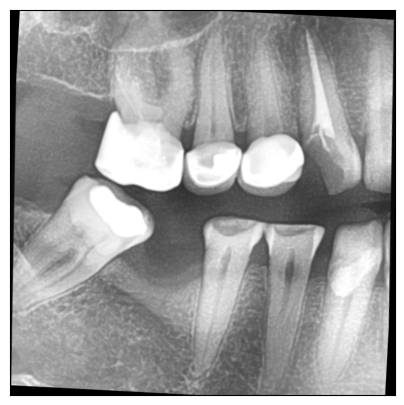

In [7]:
figsize = (5, 5)
angle = -3
angle_str = str(abs(angle)).replace('.', '_')

# for f, im_file_name in enumerate(file_name_list[:50]):

# im_file_name = 'val_train_143_03_00.png'
f = 0
im_file_name = 'val_train_17_14_07.png'

# Create output image path
output_image_file_name = f'{im_file_name.split('.')[0]}_ang_{angle_str}.png'
output_image_file = os.path.join(output_dir, output_image_file_name)

print()
print(f'{f+1}/{len(file_name_list)}: {output_image_file_name}')
im_file = os.path.join(image_dir, im_file_name)

# Load the image
im = ImageData().load_image(im_file)

# Convert to RGB image
im = ImageData().np2color(im)

# Apply some transformation (checking robustness of the prediction)
transform = alb.Rotate(angle_range=(angle, angle), p=1)
transformed_im = transform(image=im)['image']

fig, ax = plt.subplots(figsize=figsize)
ax.imshow(transformed_im)
ax.set(xticks=[], yticks=[])
plt.savefig(output_image_file, bbox_inches='tight')
plt.show()

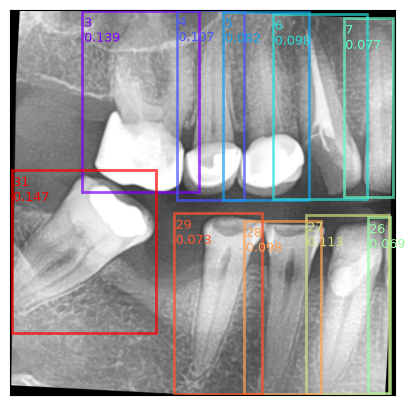

In [8]:
# Get all the predictions for the image
predictions = dtr.predict_on_image(transformed_im, threshold=0.065)

# Create a data frame
predictions_df = pd.DataFrame(predictions)

# Convert categories into tooth positions
predictions_df = predictions_df.\
    assign(pos=predictions_df['category_id'].apply(lambda c: int(id2label.get(c)))).\
    sort_values(by=['pos', 'score'], ascending=False).\
    reset_index(drop=True)

# If we have more than one prediction, take the one with the higher score
predictions_df = predictions_df.groupby(by='pos').\
    first().\
    reset_index(drop=False).\
    sort_values(by='pos', ascending=True).\
    reset_index(drop=True)

# Make lists of bounding boxes and predicted positions
box_list = predictions_df['bbox'].tolist()
pos_list = predictions_df['pos'].tolist()
scr_list = predictions_df['score'].tolist()
label_list = [f'{pos}\n{scr:.3f}' for pos, scr in zip(pos_list, scr_list)]

# Create output image path
output_image_file_name = f'{im_file_name.split('.')[0]}_ang_{angle_str}_pred.png'
output_image_file = os.path.join(output_dir, output_image_file_name)

# Paint the predictions on the image
fig, ax = plt.subplots(figsize=figsize)
ax = plot_boxes(image=transformed_im,
                ax=ax,
                box_list=box_list, 
                label_list=label_list,
                linewidth=2.0,
                fontsize=9)
plt.savefig(output_image_file, bbox_inches='tight')
plt.show()

### Compare with Claude output ###
Opus 4.8 Effort=High

You are a powerful AI system in a dental clinic. 
You excel at analyzing dental radiographs and diagnosing oral diseases.

Given the following image, please

(1) Describe the image
(2) Provide the number of teeth in the image
(3) Provide the bounding box coordinates of the teeth identified as a list of integers
(4) Provide a list of tooth position numbers accoring to the ADA numbering system

[[88, 68, 198, 203], [176, 34, 250, 203], [240, 40, 358, 205], [42, 186, 168, 322], [200, 205, 312, 320], [326, 210, 403, 320]]
[[88, 68, 110, 135], [176, 34, 74, 169], [240, 40, 118, 165], [42, 186, 126, 136], [200, 205, 112, 115], [326, 210, 77, 110]]


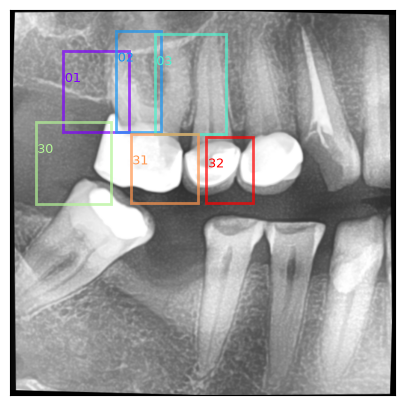

In [12]:
cbox_list = [[88,68,198,203],[176,34,250,203],[240,40,358,205],[42,186,168,322],[200,205,312,320],[326,210,403,320]]

pos_list = [1, 2, 3, 30, 31, 32]

print(cbox_list)
x_lim = (0, transformed_im.shape[1])
y_lim = (0, transformed_im.shape[0])
cbox_list = [clipxywh(xyxy2xywh(box), xlim=x_lim, ylim=y_lim, decimals=0) for box in cbox_list]
print(cbox_list)

clabel_list = [f'{str(pos).zfill(2)}' for pos in pos_list]

# Create output image path
output_image_file_name = f'{im_file_name.split('.')[0]}_ang_{angle_str}_claude.png'
output_image_file = os.path.join(output_dir, output_image_file_name)

# Paint the CLAUDE predictions on the image
fig, ax = plt.subplots(figsize=figsize)
ax = plot_boxes(image=transformed_im,
                ax=ax,
                box_list=cbox_list, 
                label_list=clabel_list,
                linewidth=2.0,
                fontsize=9)

plt.savefig(output_image_file, bbox_inches='tight')
plt.show()

### Do this again with the rotated image ###

[[93, 95, 182, 208], [176, 122, 252, 216], [244, 128, 316, 212], [34, 172, 138, 302], [188, 203, 268, 342], [258, 208, 338, 348]]
[[93, 95, 89, 113], [176, 122, 76, 94], [244, 128, 72, 84], [34, 172, 104, 130], [188, 203, 80, 139], [258, 208, 80, 140]]


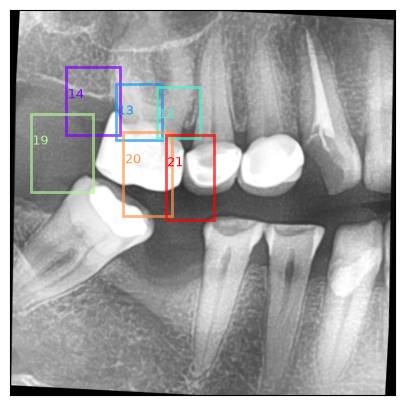

In [16]:
cbox_list = [[93, 95, 182, 208], [176, 122, 252, 216], [244, 128, 316, 212], [34, 172, 138, 302], [188, 203, 268, 342], [258, 208, 338, 348]]

pos_list = [14, 13, 12, 19, 20, 21]

print(cbox_list)
x_lim = (0, transformed_im.shape[1])
y_lim = (0, transformed_im.shape[0])
cbox_list = [clipxywh(xyxy2xywh(box), xlim=x_lim, ylim=y_lim, decimals=0) for box in cbox_list]
print(cbox_list)

clabel_list = [f'{str(pos).zfill(2)}' for pos in pos_list]

# Create output image path
output_image_file_name = f'{im_file_name.split('.')[0]}_ang_{angle_str}_pred.png'
output_image_file = os.path.join(output_dir, output_image_file_name)

# Paint the CLAUDE predictions on the image
fig, ax = plt.subplots(figsize=figsize)
ax = plot_boxes(image=transformed_im,
                ax=ax,
                box_list=cbox_list, 
                label_list=clabel_list,
                linewidth=2.0,
                fontsize=9)

plt.savefig(output_image_file, bbox_inches='tight')
plt.show()